# Probability Density Function (PDF)

PDF stands for Probability Density Function. It's a mathematical function that describes the probability distribution of a **continuous random variable**, things like height, weight, time, or total_bill, where values can be any number within a range, not just whole countable steps.

This is the continuous counterpart to PMF, which we used for discrete variables like dice rolls or table size.

![PDF](./assets/PDF/pdfFunctionImage.avif)


This bell shaped curve is a classic example of a PDF, specifically the normal distribution. Unlike a PMF's bar chart, a PDF is a smooth continuous curve, since the random variable itself can take infinitely many values, not just a handful of countable outcomes.

Now let's answer a few important questions about what this curve actually means.

## 1. Why "Density" and Not "Probability"?

In a PMF, the y axis was literally probability. You could look at a bar and read off, for example, P(X = 2) = 0.64 directly.

A PDF's y axis is different. It shows **density**, not probability. This is because for a continuous variable, the probability of hitting any one exact value is actually zero. Think about height. What's the probability someone is exactly 170.00000... cm tall, with infinite decimal precision? Practically zero, since there are infinitely many possible exact values nearby.

So instead of asking "what's the probability of this exact point," a PDF asks "how densely packed are values around this point, compared to other points." A taller part of the curve means values are more concentrated there, not that any single exact value is more probable.

## 2. What Does the Area Under the Graph Represent?

Since a single exact point has zero probability, we can't read probability directly off the curve's height like we did with a PMF bar. Instead, probability in a PDF comes from **area under the curve**, over some range.

For example, the probability that X falls between 1 and 2 isn't the height of the curve at those points. It's the area of the region under the curve between x = 1 and x = 2.

This is also why the total area under the entire curve must equal exactly 1, just like a PMF's probabilities all had to sum to 1. The whole curve together represents 100% of all possible outcomes.

## 3. How to Calculate Probability Then?

Since probability is an area, not a point, we calculate it using **integration**, the calculus tool for finding area under a curve.

$$P(a \le X \le b) = \int_{a}^{b} f(x)\, dx$$

This reads as: the probability that X falls between a and b equals the area under the PDF curve, between those two points.

We don't need to solve these integrals by hand every time though. In practice, libraries like `scipy` can calculate this area for us directly, which we'll see shortly with a real example.

## What Does a Density Value Actually Mean?

Density is probability per unit width, not a probability on its own.

If 5 out of 100 points fall between x = 1 and x = 2, the probability of landing in that range is 0.05. Dividing by the width of the range (1 unit) gives the density: 0.05.

This matters because the same probability packed into a narrower range gives a higher density. If those same 5 points had fallen between 1 and 1.1 instead, the probability would still be 0.05, but the density would jump to 0.5, since the same amount of probability is now squeezed into a much smaller space.

One thing to be careful about: a density value isn't naturally tied to one single x point. It represents the density across a range. A true PDF curve shows a distinct density value at every single x, not one flat number spread across a whole block, that distinction is exactly what separates a rough histogram-style estimate from a smooth, continuous PDF curve.

We'll see how these smooth curves are actually built, using histograms, KDE, and kernels, in the next section.

## Parametric Density Estimation

Now that I understand what density actually means, let's look at how we go from real data to an actual curve. There are two broad approaches: parametric and non parametric. I'll start with parametric.

**Parametric density estimation** means assuming the data follows a known, well studied distribution shape, like normal, exponential, or Poisson, then finding the right parameters (like mean and standard deviation for a normal distribution) that make that known formula fit the data as closely as possible.

So instead of building a custom curve from scratch, I pick a ready made mathematical formula and tune its settings to match my data.

**Why this is useful:** if the data genuinely resembles a known distribution, this approach is simple and fast, and gives a clean formula I can reuse. Plug in any x and instantly get a density value, no need to recompute anything from the raw data again.

**The catch:** it only works well if the assumption is right. If I assume the data is normally distributed but it's actually skewed or has multiple peaks, the fitted curve ends up being a poor, misleading representation of the real data.

## Fitting a Normal Distribution to Data

Let's generate a dataset, check if it looks like a normal distribution by plotting its histogram, then use the normal distribution formula to calculate density values and plot the fitted curve on top.

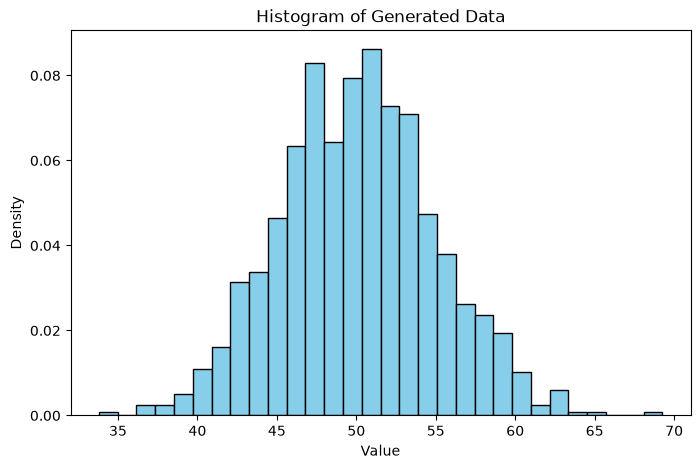

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
data = np.random.normal(loc=50, scale=5, size=1000)

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('Histogram of Generated Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

The histogram looks roughly bell shaped, centered around 50. This suggests a normal distribution could be a good fit. Let's calculate the mean and standard deviation from this data, then use the normal distribution formula to draw the theoretical curve on top.

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}$$

In [7]:
data

array([52.48357077, 49.30867849, 53.23844269, 57.61514928, 48.82923313,
       48.82931522, 57.89606408, 53.83717365, 47.65262807, 52.71280022,
       47.68291154, 47.67135123, 51.20981136, 40.43359878, 41.37541084,
       47.18856235, 44.9358444 , 51.57123666, 45.45987962, 42.93848149,
       57.32824384, 48.8711185 , 50.33764102, 42.87625907, 47.27808638,
       50.55461295, 44.24503211, 51.87849009, 46.99680655, 48.54153125,
       46.99146694, 59.26139092, 49.93251388, 44.71144536, 54.11272456,
       43.89578175, 51.04431798, 40.20164938, 43.35906976, 50.98430618,
       53.6923329 , 50.85684141, 49.42175859, 48.49448152, 42.60739005,
       46.40077896, 47.69680615, 55.28561113, 51.71809145, 41.18479922,
       51.62041985, 48.0745886 , 46.61539   , 53.05838144, 55.15499761,
       54.6564006 , 45.80391238, 48.45393812, 51.65631716, 54.87772564,
       47.60412881, 49.07170512, 44.46832513, 44.01896688, 54.06262911,
       56.78120014, 49.63994939, 55.01766449, 51.80818013, 46.77

In [4]:
mu = data.mean()
sigma = data.std()

print("Mean:", mu)
print("Standard deviation:", sigma)

x_values = np.linspace(data.min(), data.max(), 200)

# applying the formula directly
densities = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x_values - mu) ** 2) / (2 * sigma ** 2))

Mean: 50.096660279111624
Standard deviation: 4.893631038736771


In [6]:
densities

array([3.17120908e-04, 3.57795761e-04, 4.03152495e-04, 4.53656733e-04,
       5.09811016e-04, 5.72156607e-04, 6.41275231e-04, 7.17790757e-04,
       8.02370778e-04, 8.95728088e-04, 9.98621999e-04, 1.11185950e-03,
       1.23629622e-03, 1.37283713e-03, 1.52243704e-03, 1.68610071e-03,
       1.86488274e-03, 2.05988698e-03, 2.27226565e-03, 2.50321793e-03,
       2.75398814e-03, 3.02586339e-03, 3.32017071e-03, 3.63827364e-03,
       3.98156813e-03, 4.35147798e-03, 4.74944951e-03, 5.17694567e-03,
       5.63543944e-03, 6.12640654e-03, 6.65131760e-03, 7.21162948e-03,
       7.80877612e-03, 8.44415866e-03, 9.11913500e-03, 9.83500879e-03,
       1.05930179e-02, 1.13943225e-02, 1.22399926e-02, 1.31309954e-02,
       1.40681824e-02, 1.50522762e-02, 1.60838574e-02, 1.71633514e-02,
       1.82910157e-02, 1.94669269e-02, 2.06909686e-02, 2.19628194e-02,
       2.32819422e-02, 2.46475734e-02, 2.60587139e-02, 2.75141205e-02,
       2.90122986e-02, 3.05514965e-02, 3.21297011e-02, 3.37446345e-02,
      

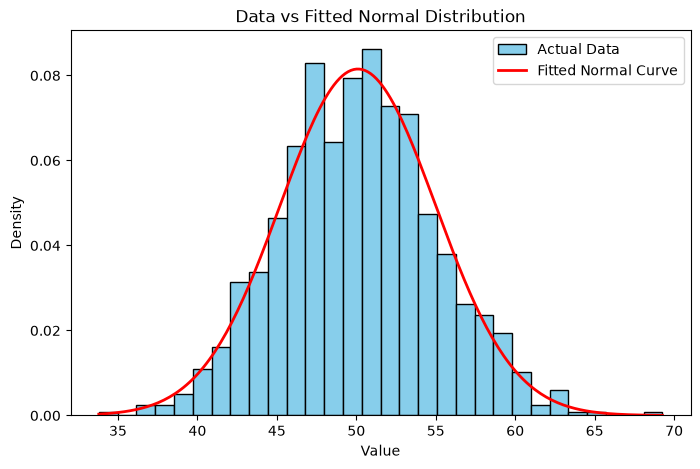

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, density=True, color='skyblue', edgecolor='black', label='Actual Data')
plt.plot(x_values, densities, color='red', linewidth=2, label='Fitted Normal Curve')
plt.title('Data vs Fitted Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Testing the Formula on Real Data

Let's switch to a real dataset and pick a specific range of values. We'll calculate the probability of falling in that range two different ways:

1. **Manually**, by counting how many real data points actually fall in that range.
2. **Using the fitted normal formula**, by calculating the area under the curve (integration) over that same range.

If the data genuinely resembles a normal distribution, these two numbers should be close.

In [12]:
import seaborn as sns

df = sns.load_dataset("tips")
values = df['total_bill']

mu = values.mean()
sigma = values.std()

print("Mean:", mu)
print("Standard deviation:", sigma)

Mean: 19.78594262295082
Standard deviation: 8.902411954856856


In [18]:
lower = 15
upper = 20

count_in_range = ((values >= lower) & (values <= upper)).sum()
total_count = len(values)

manual_probability = count_in_range / total_count
probability_density = manual_probability / (upper - lower)  # probability per unit width

print(f"Total count: {total_count}")
print(f"Points between {lower} and {upper}: {count_in_range}")
print(f"Manual probability: {manual_probability:.4f}")
print(f"Manual probability density: {probability_density:.4f}")

Total count: 244
Points between 15 and 20: 67
Manual probability: 0.2746
Manual probability density: 0.0549


In [19]:
from scipy.stats import norm

formula_probability = norm.cdf(upper, loc=mu, scale=sigma) - norm.cdf(lower, loc=mu, scale=sigma)
print(f"Formula-based probability (area under curve): {formula_probability:.4f}")

print(f"\nManual probability: {manual_probability:.4f}")
print(f"Formula probability: {formula_probability:.4f}")

Formula-based probability (area under curve): 0.2142

Manual probability: 0.2746
Formula probability: 0.2142


In [20]:
density_at_midpoint = norm.pdf(17.5, loc=mu, scale=sigma)
print(f"Manual density (over range 15-20): {probability_density:.4f}")
print(f"Formula density (at midpoint 17.5): {density_at_midpoint:.4f}")

Manual density (over range 15-20): 0.0549
Formula density (at midpoint 17.5): 0.0434


## What This Comparison Tells Us

The manual probability (0.2746) and the formula-based probability (0.2142) don't match closely. This is a real and useful finding, not an error.

It tells us `total_bill` doesn't perfectly follow a normal distribution. Since the manual, real-data probability is higher than what the normal formula predicts, it suggests more bills are genuinely clustered in this 15 to 20 range than a perfectly symmetric bell curve would expect. This is a sign of **right skew**, common in real world cost and income data, where most values sit in a moderate range, but a handful of unusually large bills pull the distribution's tail out to the right.

This is exactly the catch with parametric density estimation we noted earlier. Assuming a distribution shape (like normal) is only useful if the real data actually resembles that shape. Here, forcing a normal curve onto `total_bill` gives a reasonable but imperfect approximation, since the data's actual shape is somewhat skewed, not symmetric.

This naturally leads to the next question: if parametric methods don't fit well, what's the alternative? That's where non-parametric methods like KDE come in, since they don't assume any fixed shape at all, they let the real data speak for itself.

<Axes: xlabel='total_bill', ylabel='Count'>

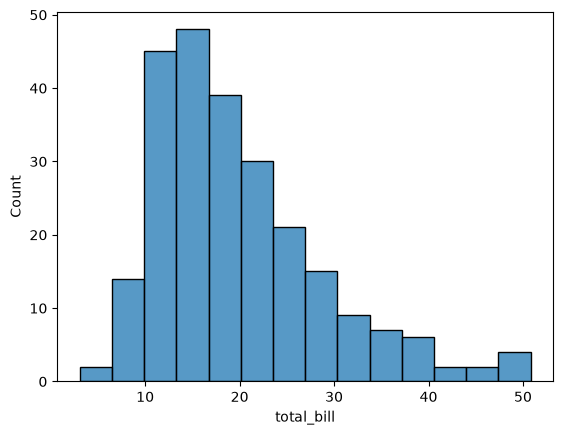

In [21]:
sns.histplot(df['total_bill'])

This histogram makes the skew obvious. If `total_bill` were truly normal, this chart would look symmetric, mirrored evenly on both sides of the peak. Instead, the bars rise sharply on the left and trail off slowly on the right, a classic right skewed shape.

This confirms what the probability comparison showed earlier. A normal distribution assumes symmetry around the mean, but real bill amounts don't behave that way. Most tables spend a moderate amount, while a smaller number of tables run up unusually large bills, stretching the distribution's tail to the right.